чё надо потестить:
- все алгоритмы на разных объёмах данных
- svm на легко и трудно разделимых + объяснение с визуализацией отличий двух этих типов
- разные инициализации центроидов для kmeans и фиксированный random state
- Kmeans и svm стоит потестить на разреженных данных

In [ ]:
import time
import os
import threadpoolctl

os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["BLIS_NUM_THREADS"] = "1"
os.environ["OMP_NUM_THREADS"] = "1"
threadpoolctl.threadpool_limits(1, "blas")
threadpoolctl.threadpool_limits(1, "openmp")

import numpy as np
import scipy.sparse as sp

from sklearn.datasets import make_regression, make_classification
from sklearn.metrics import mean_absolute_error, accuracy_score
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt


## Линейная регрессия

In [ ]:
# density = 0.1
# X = sp.random(matr_len, feat, density=density, format='csr')
# y = np.random.randint(1, 10, size=matr_len)

In [2]:
def LinReg_comprasion(X_train, X_test, y_train, y_test, N_iter, verbose):
    
    from lin_mod import NewLinearRegression
    from sklearn.linear_model import LinearRegression

    NewLinReg = NewLinearRegression(n_jobs=1)
    OldLinReg = LinearRegression(n_jobs=1)

    if verbose: print(f"[INFO] X_train size: {X_train.size}\n")
    
    time_arr_new = []
    time_arr_old = []
    MAE_new = []
    MAE_old = []
    for i in range(N_iter):
        
        start_time_1 = time.perf_counter()  
        NewLinReg.fit(X_train, y_train)
        end_time_1 = time.perf_counter()
        
        execution_time_1 = end_time_1 - start_time_1
        time_arr_new.append(execution_time_1)
        
        metr_1 = mean_absolute_error(y_test, NewLinReg.predict(X_test))
        MAE_new.append(metr_1)
        if verbose: print(f"NewLinReg, итерация - {i+1}: Время - {execution_time_1:.6f} сек.  MAE - {metr_1:.4f}")
        
        start_time_2 = time.perf_counter()  
        OldLinReg.fit(X_train, y_train)
        end_time_2 = time.perf_counter()
        
        execution_time_2 = end_time_2 - start_time_2
        time_arr_old.append(execution_time_2)
        
        metr_2 = mean_absolute_error(y_test, OldLinReg.predict(X_test))
        MAE_old.append(metr_2)
        if verbose: print(f"OldLinReg, итерация - {i+1}: Время - {execution_time_2:.6f} сек.  MAE - {metr_2:.4f}")

    t_old = np.mean(time_arr_old)
    t_new = np.mean(time_arr_new)
    M_old = np.mean(MAE_old)
    M_new = np.mean(MAE_new)
    if verbose:
        print(f"\n- Итоговые результаты старой OldLinReg: \n Время - {t_old:.6f} сек.  MAE - {M_old:.4f}")
        print(f"\n- Итоговые результаты новой NewLinReg: \n Время - {t_new:.6f} сек.  MAE - {M_new:.4f}\n")
    
    return t_old, M_old, t_new, M_new

ValueError: The number of FixedLocator locations (5), usually from a call to set_ticks, does not match the number of labels (6).

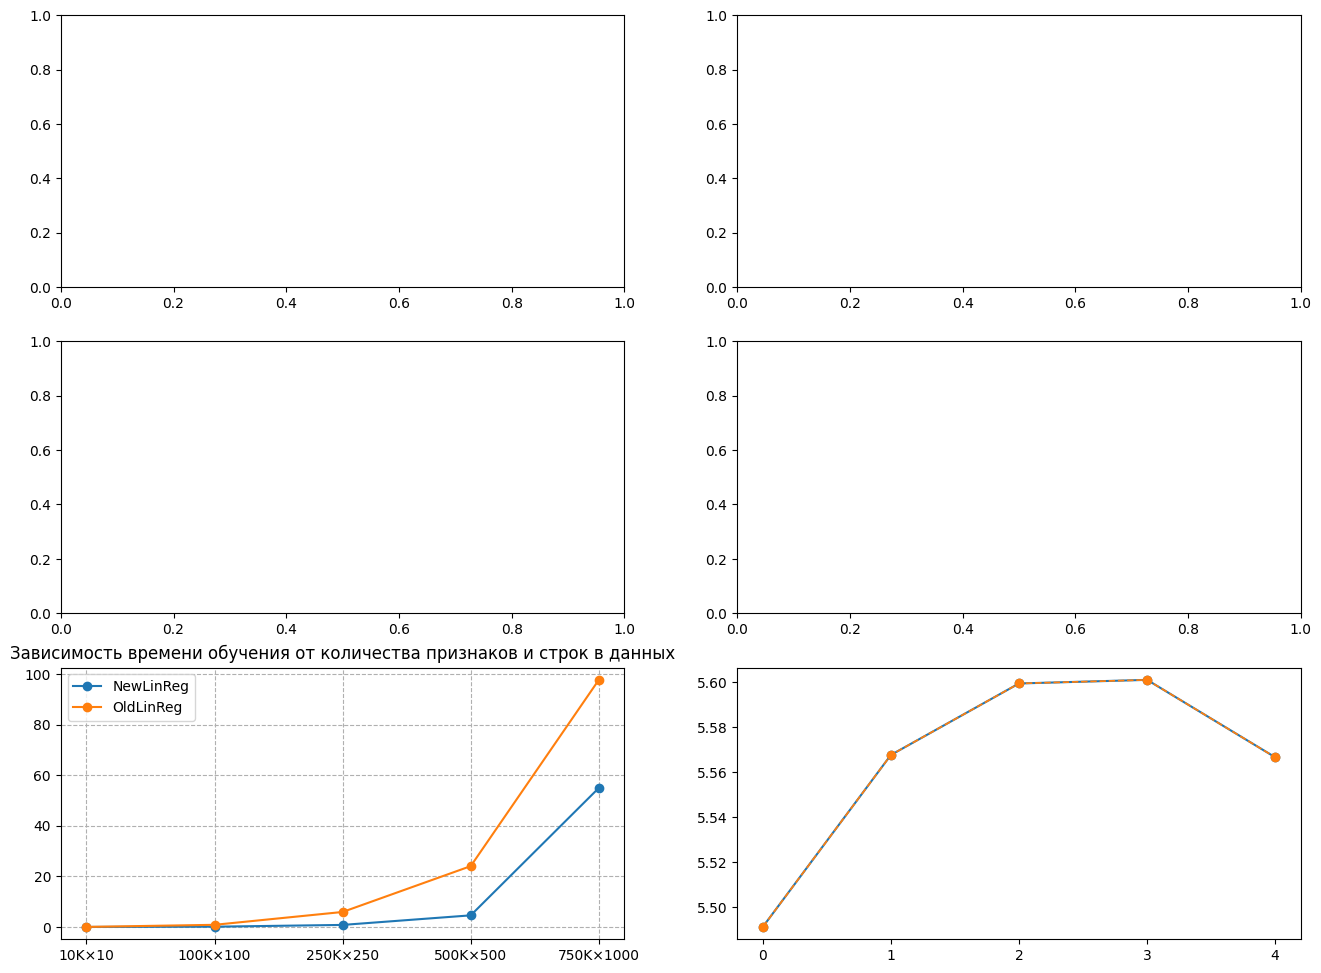

In [ ]:
N_iter = 4
matr_len = [10_000, 100_000, 250_000, 500_000, 750_000, 1_000_000]
feat = [10, 100, 250, 500, 1_000, 2_500]

time_arr_plot_New_1 = []
time_arr_plot_Old_1 = []
MAE_arr_plot_New_1 = []
MAE_arr_plot_Old_1 = []

fig, axs = plt.subplots(3, 2, figsize=(16, 12))

# for l in matr_len:
#     X, y = make_regression(n_samples=l, n_features=feat[0], noise=7, random_state=40)
#     X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

#     t_o, M_o, t_n, M_n = LinReg_comprasion(X_train, X_test, y_train, y_test, N_iter, False)
#     time_arr_plot_New_1.append(t_n)
#     time_arr_plot_Old_1.append(t_o)
#     MAE_arr_plot_New_1.append(M_n)
#     MAE_arr_plot_Old_1.append(M_o)
    
    
# axs[0][0].plot(matr_len, time_arr_plot_New_1, marker='o', linestyle='-', label='NewLinReg')
# axs[0][0].plot(matr_len, time_arr_plot_Old_1, marker='o', linestyle='-', label='OldLinReg')
# axs[0][0].legend()
# axs[0][0].set_title('Зависимость времени обучения от количества строк в данных')
# axs[0][0].grid(ls='--')

# axs[0][1].plot(matr_len, MAE_arr_plot_New_1, marker='o', linestyle='-', label='NewLinReg')
# axs[0][1].plot(matr_len, MAE_arr_plot_Old_1, marker='o', linestyle='--', label='OldLinReg', linewidth=1.25)
# axs[0][1].legend()
# axs[0][1].set_title('Зависимость MAE от количества строк в данных')
# axs[0][1].grid(ls='--')

# time_arr_plot_New_1 = []
# time_arr_plot_Old_1 = []
# MAE_arr_plot_New_1 = []
# MAE_arr_plot_Old_1 = []

# for f in feat:
#     X, y = make_regression(n_samples=matr_len[0], n_features=f, noise=7, random_state=40)
#     X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

#     t_o, M_o, t_n, M_n = LinReg_comprasion(X_train, X_test, y_train, y_test, N_iter, False)
#     time_arr_plot_New_1.append(t_n)
#     time_arr_plot_Old_1.append(t_o)
#     MAE_arr_plot_New_1.append(M_n)
#     MAE_arr_plot_Old_1.append(M_o)
    
    
# axs[1][0].plot(feat, time_arr_plot_New_1, marker='o', linestyle='-', label='NewLinReg')
# axs[1][0].plot(feat, time_arr_plot_Old_1, marker='o', linestyle='-', label='OldLinReg')
# axs[1][0].legend()
# axs[1][0].set_title('Зависимость времени обучения от количества признаков в данных')
# axs[1][0].grid(ls='--')

# axs[1][1].plot(feat, MAE_arr_plot_New_1, marker='o', linestyle='-', label='NewLinReg')
# axs[1][1].plot(feat, MAE_arr_plot_Old_1, marker='o', linestyle='--', label='OldLinReg', linewidth=1.25)
# axs[1][1].legend()
# axs[1][1].set_title('Зависимость MAE от количества признаков в данных')
# axs[1][1].grid(ls='--')

N_iter = 3
time_arr_plot_New_1 = []
time_arr_plot_Old_1 = []
MAE_arr_plot_New_1 = []
MAE_arr_plot_Old_1 = []

range_indxs = range(len(matr_len)-1)
for idx in range_indxs:
    X, y = make_regression(n_samples=matr_len[idx], n_features=feat[idx], noise=7, random_state=40)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

    t_o, M_o, t_n, M_n = LinReg_comprasion(X_train, X_test, y_train, y_test, N_iter, False)
    time_arr_plot_New_1.append(t_n)
    time_arr_plot_Old_1.append(t_o)
    MAE_arr_plot_New_1.append(M_n)
    MAE_arr_plot_Old_1.append(M_o)
    
    
labels = [f"{n//1000}K×{m}" for n, m in zip(matr_len, feat)]
axs[2][0].plot(range_indxs, time_arr_plot_New_1, marker='o', linestyle='-', label='NewLinReg')
axs[2][0].plot(range_indxs, time_arr_plot_Old_1, marker='o', linestyle='-', label='OldLinReg')
axs[2][0].set_xticks(range_indxs, labels[:5])
axs[2][0].legend()
axs[2][0].set_title('Зависимость времени обучения от количества признаков и строк в данных')
axs[2][0].grid(ls='--')

axs[2][1].plot(range_indxs, MAE_arr_plot_New_1, marker='o', linestyle='-', label='NewLinReg')
axs[2][1].plot(range_indxs, MAE_arr_plot_Old_1, marker='o', linestyle='--', label='OldLinReg', linewidth=1.25)
axs[2][1].set_xticks(range_indxs, labels[:5])
axs[2][1].legend()
axs[2][1].set_title('Зависимость MAE от количества признаков и строк в данных')
axs[2][1].grid(ls='--')

plt.tight_layout()
plt.show()

Коэффициенты: [2.0040375  2.99616061], intercept: -0.00


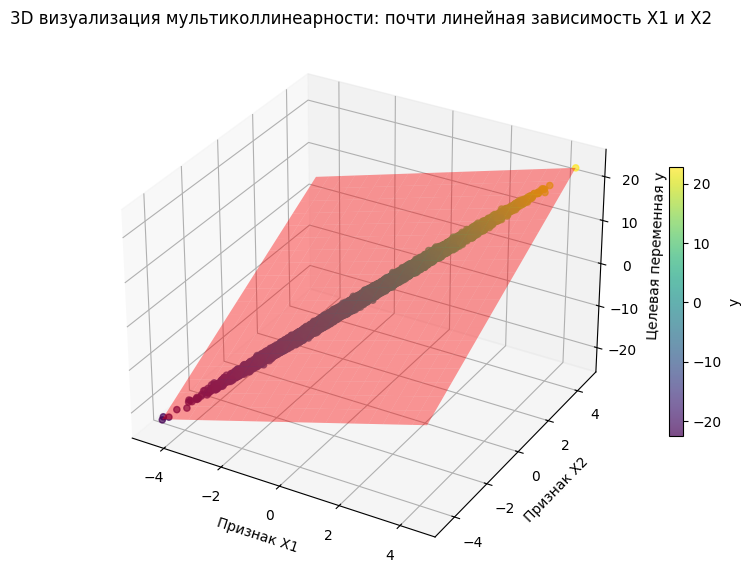

In [38]:


# Параметры
np.random.seed(42)
n_samples = 100_000

# Первый признак
x1 = np.random.randn(n_samples)

# Второй признак = x1 + сильный шум (корреляция ~0.98)
noise = 0.1 * np.random.randn(n_samples)
x2 = x1 + noise

# Целевая переменная: y = 2*x1 + 3*x2 + шум
y_colin = 2 * x1 + 3 * x2 + 0.1 * np.random.randn(n_samples)

# Матрица признаков
X_colin = np.column_stack((x1, x2))

# Обучение модели
model = LinearRegression()
model.fit(X_colin, y_colin)
print(f"Коэффициенты: {model.coef_}, intercept: {model.intercept_:.2f}")

# Создаём сетку для плоскости регрессии
x1_grid = np.linspace(x1.min(), x1.max(), 20)
x2_grid = np.linspace(x2.min(), x2.max(), 20)
X1_grid, X2_grid = np.meshgrid(x1_grid, x2_grid)
y_grid = model.intercept_ + model.coef_[0] * X1_grid + model.coef_[1] * X2_grid

# Рисуем
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Точки данных
scat = ax.scatter(x1, x2, y_colin, c=y_colin, cmap='viridis', s=20, alpha=0.7)

# Поверхность регрессии
ax.plot_surface(X1_grid, X2_grid, y_grid, alpha=0.4, color='red', label='Регрессия')

ax.set_xlabel('Признак X1')
ax.set_ylabel('Признак X2')
ax.set_zlabel('Целевая переменная y')
ax.set_title('3D визуализация мультиколлинеарности: почти линейная зависимость X1 и X2')
plt.colorbar(scat, ax=ax, shrink=0.5, label='y')
plt.show()

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X_colin, y_colin, test_size=0.2)

LinReg_comprasion(X_train, X_test, y_train, y_test, N_iter)

NewLinReg, итерация - 1: Время - 0.005434 сек.  MAE - 0.0801
OldLinReg, итерация - 1: Время - 0.009309 сек.  MAE - 0.0801
NewLinReg, итерация - 2: Время - 0.006478 сек.  MAE - 0.0801
OldLinReg, итерация - 2: Время - 0.007872 сек.  MAE - 0.0801
NewLinReg, итерация - 3: Время - 0.004641 сек.  MAE - 0.0801
OldLinReg, итерация - 3: Время - 0.009009 сек.  MAE - 0.0801
NewLinReg, итерация - 4: Время - 0.005369 сек.  MAE - 0.0801
OldLinReg, итерация - 4: Время - 0.004773 сек.  MAE - 0.0801
NewLinReg, итерация - 5: Время - 0.004817 сек.  MAE - 0.0801
OldLinReg, итерация - 5: Время - 0.004599 сек.  MAE - 0.0801

- Итоговые результаты старой OldLinReg: 
 Время - 0.007112 сек.  MAE - 0.0801

- Итоговые результаты новой NewLinReg: 
 Время - 0.005348 сек.  MAE - 0.0801


In [37]:
import numpy as np
from scipy import linalg

# 1. Генерация данных с экстремальной коллинеарностью
np.random.seed(42)
n = 10000
x1 = np.random.randn(n)
# x2 почти идеально равен x1 + микроскопический шум
eps = 1e-8  # очень малый шум
x2 = x1 + eps * np.random.randn(n)

X = np.column_stack([x1, x2])

# Истинные коэффициенты: y = 3*x1 + 2*x2 + шум
true_coef = np.array([3.0, 2.0])
y = X @ true_coef + 0.1 * np.random.randn(n)

print(f"Число обусловленности X: {np.linalg.cond(X):.2e}")
print(f"Число обусловленности XtX: {np.linalg.cond(X.T @ X):.2e}")
print()


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

LinReg_comprasion(X_train, X_test, y_train, y_test, N_iter)

Число обусловленности X: 2.00e+08
Число обусловленности XtX: 7.83e+15

NewLinReg, итерация - 1: Время - 0.001918 сек.  MAE - 0.0794
OldLinReg, итерация - 1: Время - 0.001595 сек.  MAE - 0.0794
NewLinReg, итерация - 2: Время - 0.001516 сек.  MAE - 0.0794
OldLinReg, итерация - 2: Время - 0.000979 сек.  MAE - 0.0794
NewLinReg, итерация - 3: Время - 0.000909 сек.  MAE - 0.0794
OldLinReg, итерация - 3: Время - 0.001536 сек.  MAE - 0.0794
NewLinReg, итерация - 4: Время - 0.003187 сек.  MAE - 0.0794
OldLinReg, итерация - 4: Время - 0.001557 сек.  MAE - 0.0794
NewLinReg, итерация - 5: Время - 0.001350 сек.  MAE - 0.0794
OldLinReg, итерация - 5: Время - 0.001824 сек.  MAE - 0.0794

- Итоговые результаты старой OldLinReg: 
 Время - 0.001498 сек.  MAE - 0.0794

- Итоговые результаты новой NewLinReg: 
 Время - 0.001776 сек.  MAE - 0.0794


d:\VScode_python_projects\Сбер Практика\lin_mod.py:709: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 5.658832467229342e-17.
  self.coef_ = linalg.solve(XtX, Xty, assume_a='pos', check_finite=False).T[0]
d:\VScode_python_projects\Сбер Практика\lin_mod.py:709: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 5.658832467229342e-17.
  self.coef_ = linalg.solve(XtX, Xty, assume_a='pos', check_finite=False).T[0]
d:\VScode_python_projects\Сбер Практика\lin_mod.py:709: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 5.658832467229342e-17.
  self.coef_ = linalg.solve(XtX, Xty, assume_a='pos', check_finite=False).T[0]
d:\VScode_python_projects\Сбер Практика\lin_mod.py:709: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 5.658832467229342e-17.
  self.coef_ = linalg.solve(XtX, Xty, assume_a='pos', check_finite=False).T[0]
d:\VScode_python_projects\Сбер Практика\lin_mod.py:709: LinAlgWarning: An ill-condit

## SVM